In [19]:
from dotenv import load_dotenv
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import Image, display
from typing import Annotated

load_dotenv()


True

In [ ]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [20]:
class State(TypedDict):
    messages : Annotated[list, add_messages]
    
def chatbot(state: State)->State:
    return {"messages" : [llm.invoke(state['messages'])]}


In [26]:
builder = StateGraph(State)

builder.add_node("chatbot_node", chatbot)

builder.add_edge(START, "chatbot_node")
builder.add_edge("chatbot_node", END)

graph = builder.compile()


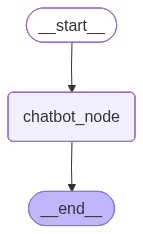

In [22]:

display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
message = {"role": "user", "content": "what is AI in 2 line"}

In [24]:
response = graph.invoke({"messages":[message]})

response["messages"]

[HumanMessage(content='what is AI in 2 line', additional_kwargs={}, response_metadata={}, id='1543029e-0199-4597-a69f-610b4de53c46'),
 AIMessage(content='Artificial Intelligence (AI) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning and problem-solving. AI uses algorithms and data to enable machines to think, learn, and act like humans, improving efficiency and accuracy in various industries and applications.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 42, 'total_tokens': 101, 'completion_time': 0.155791034, 'completion_tokens_details': None, 'prompt_time': 0.001881961, 'prompt_tokens_details': None, 'queue_time': 0.318476259, 'total_time': 0.157672995}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4623-1

In [28]:
state = None
while True:
    in_message = input("You: ")
    if in_message.lower() in {'quit', 'exit'}:
        break
    
    if state is None:
        state  = {
            "messages":[{"role": "user", "content": in_message}]
        }
    else :
        state["messages"].append({"role":"user", "content": in_message})
        
    state = graph.invoke(state)

    print("Bot: ", state['messages'][-1].content)

Bot:  Hello. It's nice to meet you. Is there something I can help you with or would you like to chat?
Bot:  As my knowledge cutoff is December 2023, I don't have real-time information. However, I can suggest ways for you to find out the current date.

You can check the current date on your device, such as a computer, phone, or tablet. Alternatively, you can search for "current date" on a search engine like Google to get the latest information.

If you'd like, I can also tell you the date I was last updated, which is December 2023. Keep in mind that this is not the current date, but rather the date of my knowledge cutoff.
